## custom datasets



In [92]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


'cpu'

In [6]:
from pathlib import Path
import requests 
import zipfile

path= Path('data/')
img_path= path / 'pizza_steak_sushi'

if img_path.is_dir():
    print(f'{img_path} directory already exist... skipping download')

else:
    print(f'{img_path} creating path...')
    img_path.mkdir(parents=True, exist_ok=True)


# Download data

with open(path / 'pizza_steak_sushi.zip', 'wb') as f:
    request= requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    print('Downloading data')
    f.write(request.content)
#unzip

with zipfile.ZipFile(path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
    print('unzipping data')
    zip_ref.extractall(img_path)

data\pizza_steak_sushi directory already exist... skipping download
unzipping data


## DATA PREPARATION AND EXPLORATION

In [11]:
import os

def walk_trough_dir(dir_path):

    '''walks thru dir_path returning its content'''

    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f'There are {len(dirnames)} directoris and {len(filenames)} images in "{dirpath}".')

In [12]:
walk_trough_dir(img_path)

There are 2 directoris and 0 images in "data\pizza_steak_sushi".
There are 3 directoris and 0 images in "data\pizza_steak_sushi\test".
There are 0 directoris and 25 images in "data\pizza_steak_sushi\test\pizza".
There are 0 directoris and 19 images in "data\pizza_steak_sushi\test\steak".
There are 0 directoris and 31 images in "data\pizza_steak_sushi\test\sushi".
There are 3 directoris and 0 images in "data\pizza_steak_sushi\train".
There are 0 directoris and 78 images in "data\pizza_steak_sushi\train\pizza".
There are 0 directoris and 75 images in "data\pizza_steak_sushi\train\steak".
There are 0 directoris and 72 images in "data\pizza_steak_sushi\train\sushi".


### VISUALIZING

data\pizza_steak_sushi\train\pizza\3821701.jpg
pizza
Random image path: data\pizza_steak_sushi\train\pizza\3821701.jpg
Image class: pizza
Image height: 288
Image width: 512


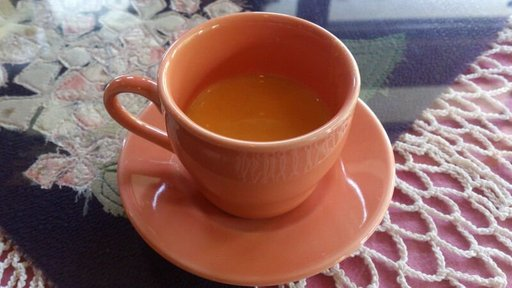

In [83]:
import random
from PIL import Image
#random.seed(42)

#1. get all image paths
img_path_list= list(img_path.glob('*/*/*.jpg'))
#img_path_list

#2 get random image
random_img= random.choice(img_path_list)
print(random_img)

#3. get image class from path name
image_class= random_img.parent.stem
print(image_class)

#4. open img
img= Image.open(random_img)

#5. print metadata 

print(f'Random image path: {random_img}')
print(f'Image class: {image_class}')
print(f'Image height: {img.height}')
print(f'Image width: {img.width}')
img

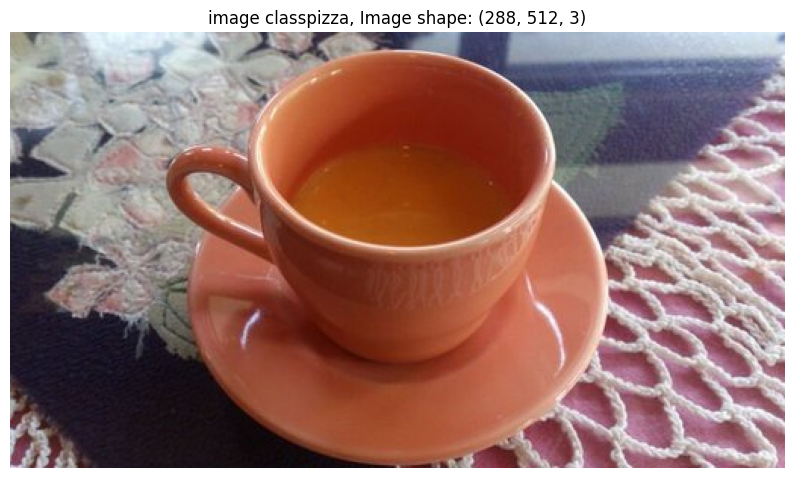

In [91]:
import numpy as np
import matplotlib.pyplot as plt

#1.  turn image into array

img_as_array= np.asarray(img)
plt.figure(figsize=(10,7))


plt.imshow(img_as_array)
plt.title(f'image class{image_class}, Image shape: {img_as_array.shape}')

plt.axis(False)

plt.show()


## TRANSFORMING DATA


In [106]:
train_data_transform= transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
]) 
test_data_transform= transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
]) 

train_data_transform(img).dtype

torch.float32

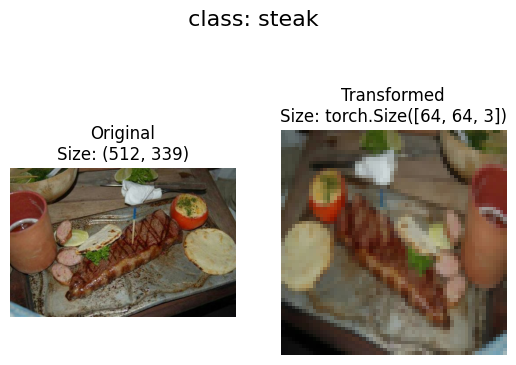

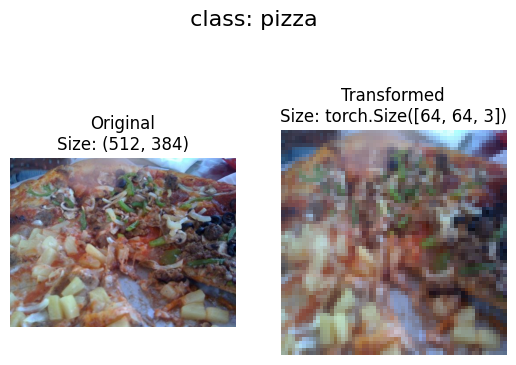

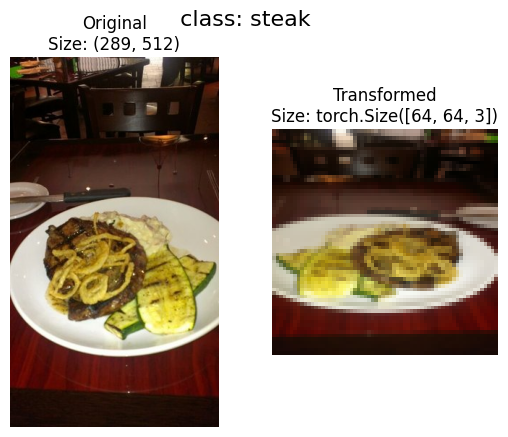

In [107]:
def plot_transformed_images(image_paths, transform, n=3, seed=None):
    
    if seed:
        random.seed(seed)

    random_img= random.sample(image_paths, k=n)    
    for image_path in random_img:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f'Original\nSize: {f.size}')
            ax[0].axis(False)

            transformed_image= train_data_transform(f)
            transformed_image= transformed_image.permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f'Transformed\nSize: {transformed_image.shape}')
            ax[1].axis(False)


            fig.suptitle(f' class: {image_path.parent.stem}', fontsize=16)
             

plot_transformed_images(image_paths=img_path_list, transform=train_data_transform, n=3, seed=None)

create dataset with imagefolder

In [ ]:

train_dir= Path("data/pizza_steak_sushi/train")
test_dir= Path("data/pizza_steak_sushi/test")

train_dataset= datasets.ImageFolder(
    root=train_dir,
    transform=train_data_transform,
    target_transform=None
)
test_dataset= datasets.ImageFolder(
    root=test_dir,
    transform=test_data_transform,
    
)

train_dataset, test_dataset


(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [110]:
class_names= train_dataset.classes
class_names

['pizza', 'steak', 'sushi']

In [112]:
class_dict= train_dataset.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [113]:
len(train_dataset), len(test_dataset)

(225, 75)

In [118]:
train_dataset.samples[0]


('data\\pizza_steak_sushi\\train\\pizza\\1008844.jpg', 0)

In [121]:
os.cpu_count()

16

In [123]:
train_dataloader= DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
    )
test_dataloader= DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
    )

for img, label in train_dataloader:
    print(img.shape, label.shape)

torch.Size([32, 3, 64, 64]) torch.Size([32])
torch.Size([32, 3, 64, 64]) torch.Size([32])
torch.Size([32, 3, 64, 64]) torch.Size([32])
torch.Size([32, 3, 64, 64]) torch.Size([32])
torch.Size([32, 3, 64, 64]) torch.Size([32])
torch.Size([32, 3, 64, 64]) torch.Size([32])
torch.Size([32, 3, 64, 64]) torch.Size([32])
torch.Size([1, 3, 64, 64]) torch.Size([1])
